# Test-Szenario A2
Wie gut transkribiert das STT-Modell das Gesprochene? (Gemessen an Anzahl Durchläufen)

_Ebenfalls anwendbar für:_
- _**Test-Szenario S1**: Wird die Antwort gleichermaßen transkribiert trotz sprachlicher Unterschiede?_

## Imports und Daten laden

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dir_path = Path(".")  # current directory
keep_cols = ["question_de", "answer_de", "max_points", "keywords", "student_answer", "human_score", "human_feedback", "rueckfrage",
             "error_type"]

dfs = []
for fp in sorted(dir_path.glob("*.tsv")):
    df_tmp = pd.read_csv(fp, sep="\t", dtype=str)
    df_tmp = df_tmp.reindex(columns=keep_cols)  # keeps order, fills missing with NA
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)  # appends; duplicates are kept
df["error_type"] = df["error_type"].astype(int)

## Calculate Perfect Transcription Rate

In [2]:
n_runs = len(df)
n_perfect = (df["error_type"] <= 1).sum()
perfect_rate = n_perfect / n_runs

n_acceptable = (df["error_type"] > 1).sum()
acceptable_rate = n_acceptable / n_runs

print(f"Runs total: {n_runs}")
print(f"Perfect (error_type=0): {n_perfect} -> {perfect_rate:.1%}")
print(f"Acceptable (error_type<=1): {n_acceptable} -> {acceptable_rate:.1%}")

Runs total: 95
Perfect (error_type=0): 61 -> 64.2%
Acceptable (error_type<=1): 34 -> 35.8%


## See Distribution: Perfect Transcription vs. Transcription contains Errors

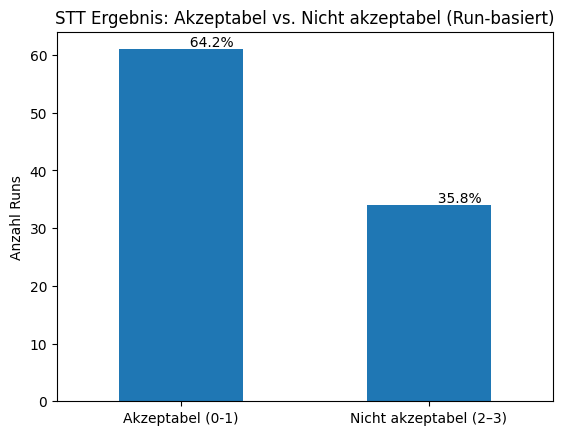

In [7]:
counts = pd.Series({
    "Akzeptabel (0-1)": n_perfect,
    "Nicht akzeptabel (2–3)": n_runs - n_perfect
})

plt.figure()
counts.plot(kind="bar")
plt.title("STT Ergebnis: Akzeptabel vs. Nicht akzeptabel (Run-basiert)")
plt.ylabel("Anzahl Runs")
plt.xticks(rotation=0)

# Textannotation mit Prozent
plt.text(0, counts.iloc[0], f"  {perfect_rate:.1%}", va="bottom")
plt.text(1, counts.iloc[1], f"  {(1-perfect_rate):.1%}", va="bottom")

plt.show()

## Distribution over all Labels

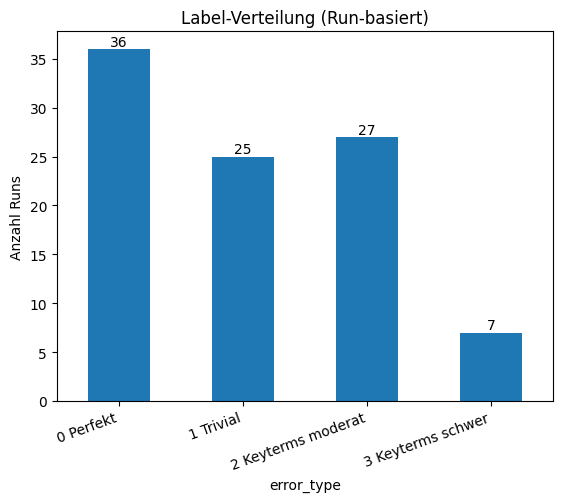

In [8]:
label_names = {
    0: "0 Perfekt",
    1: "1 Trivial",
    2: "2 Keyterms moderat",
    3: "3 Keyterms schwer"
}

dist = df["error_type"].value_counts().sort_index()
dist.index = dist.index.map(label_names.get)

plt.figure()
dist.plot(kind="bar")
plt.title("Label-Verteilung (Run-basiert)")
plt.ylabel("Anzahl Runs")
plt.xticks(rotation=20, ha="right")
plt.bar_label(plt.gca().containers[0])
plt.show()

## Final Verdict

In [9]:
if perfect_rate > 0.5:
    conclusion = f"✅ Das Modell transkribiert in den meisten Fällen alles korrekt: {perfect_rate:.1%} der Runs sind perfekt (Label=0)."
else:
    conclusion = f"⚠️ Das Modell transkribiert NICHT in den meisten Fällen alles korrekt: nur {perfect_rate:.1%} der Runs sind perfekt (Label=0)."

print(conclusion)

✅ Das Modell transkribiert in den meisten Fällen alles korrekt: 64.2% der Runs sind perfekt (Label=0).
